# Basic Statistics

+ Harald Puhr
+ 2025-10-21

[Data Source](https://github.com/ha-pu/data_files/tree/main#user-knowledge-modeling-dataset)

## Load libraries and data

In [22]:
import numpy as np
import pandas as pd
from plotnine import ggplot, aes, geom_boxplot, geom_histogram, geom_tile, facet_wrap, labs, theme_bw
from scipy import stats
from scipy.stats import ttest_ind, t

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/ha-pu/data_files/refs/heads/main/1-user_knowledge.csv")

Code variable `UNS` as type factor to better handle categorical data.

In [3]:
df["UNS"] = pd.Categorical(
    df["UNS"],
    categories=["Very Low", "Low", "Middle", "High"],
    ordered=True
)

## Inspect data frame

In [4]:
df.head()

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,Very Low
1,0.08,0.08,0.10,0.24,0.90,High
2,0.06,0.06,0.05,0.25,0.33,Low
3,0.10,0.10,0.15,0.65,0.30,Middle
4,0.08,0.08,0.08,0.98,0.24,Low


## Get frequency of skill levels

In [6]:
(
    df.groupby("UNS", observed=False)
        .size()
        .reset_index(name="n")
        .sort_values("UNS")
        .reset_index(drop=True)
)

,UNS,n
0,Very Low,50
1,Low,129
2,Middle,122
3,High,102


## Analyze study effort by skill level

In [7]:
(
    df.groupby("UNS", observed=False)
      .agg(
          n=("UNS", "size"),
          STG=("STG", "mean"),
          SCG=("SCG", "mean"),
          STR=("STR", "mean"),
          LPR=("LPR", "mean"),
          PEG=("PEG", "mean"),
      )
      .reset_index()
      .sort_values("UNS")
      .reset_index(drop=True)
)

,UNS,n,STG,SCG,STR,LPR,PEG
0,Very Low,50,0.259180,0.261900,0.354000,0.268820,0.095800
1,Low,129,0.326783,0.322798,0.424961,0.449302,0.253589
2,Middle,122,0.374574,0.367189,0.491148,0.385656,0.531393
3,High,102,0.406902,0.430500,0.509755,0.542941,0.799804


### Questions

+ Are there immediate takeaways for our efforts to increase skills (UNS)?
+ Is there one effort-related variables that stands out?

## Distribution of study effort

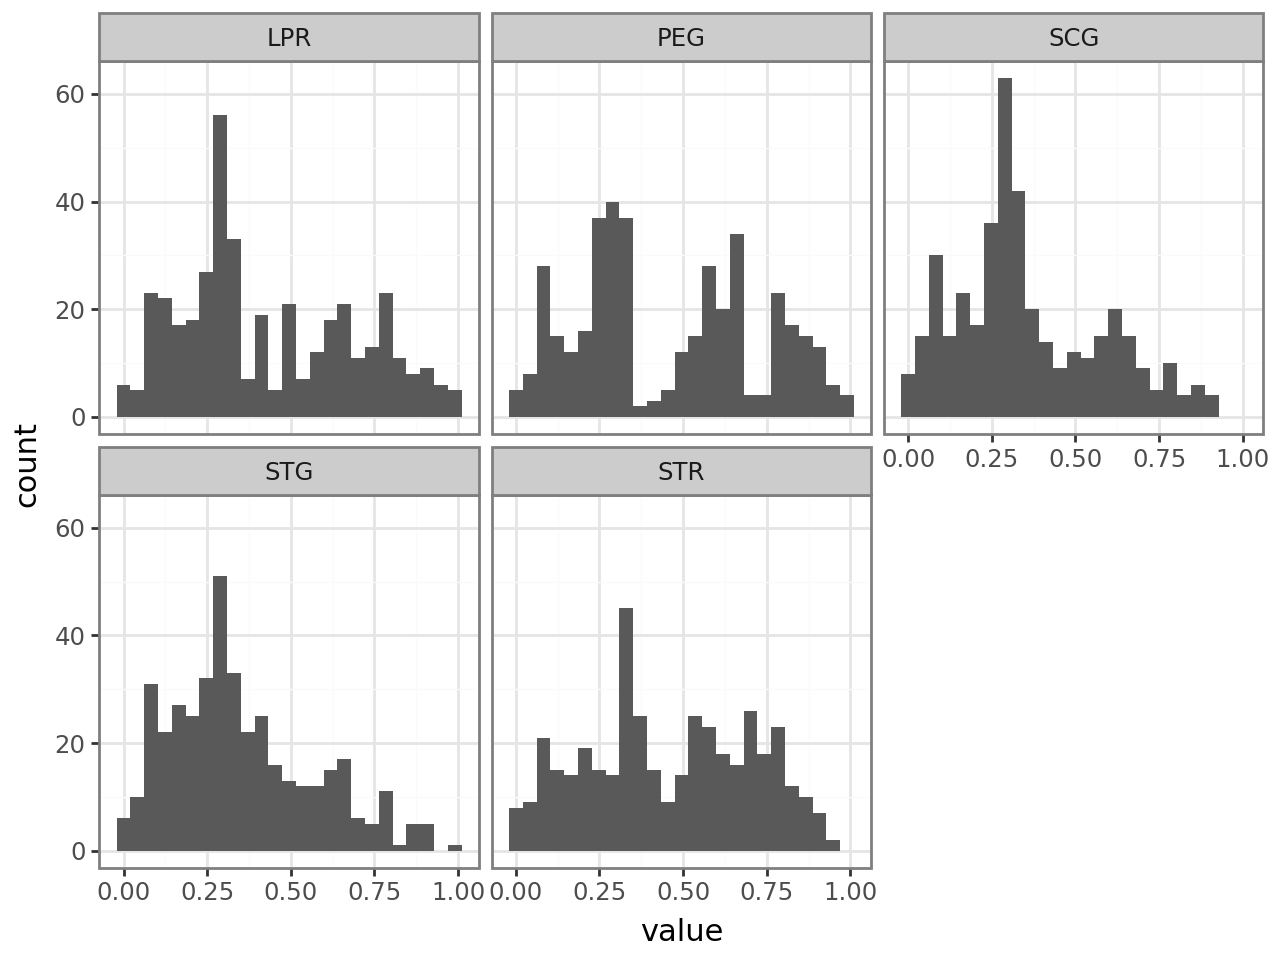

In [9]:
# melt dataframe to long format
df_long = pd.melt(
    df,
    id_vars=[c for c in df.columns if c not in ["STG", "SCG", "STR", "LPR", "PEG"]],
    value_vars=["STG", "SCG", "STR", "LPR", "PEG"],
    var_name="knowledge",
    value_name="value"
)

# ggplot histogram faceted by 'knowledge'
p = (
    ggplot(df_long)
    + geom_histogram(aes("value"), bins=25)
    + facet_wrap("~knowledge")
    + theme_bw()
)
p

### Questions

+ What do you see in the distribution of study effort variables?
+ How do the distributions differentiate?
+ Are there immediate takeaways for our efforts to increase skills (UNS)?

## Boxplot of study effort by skill level

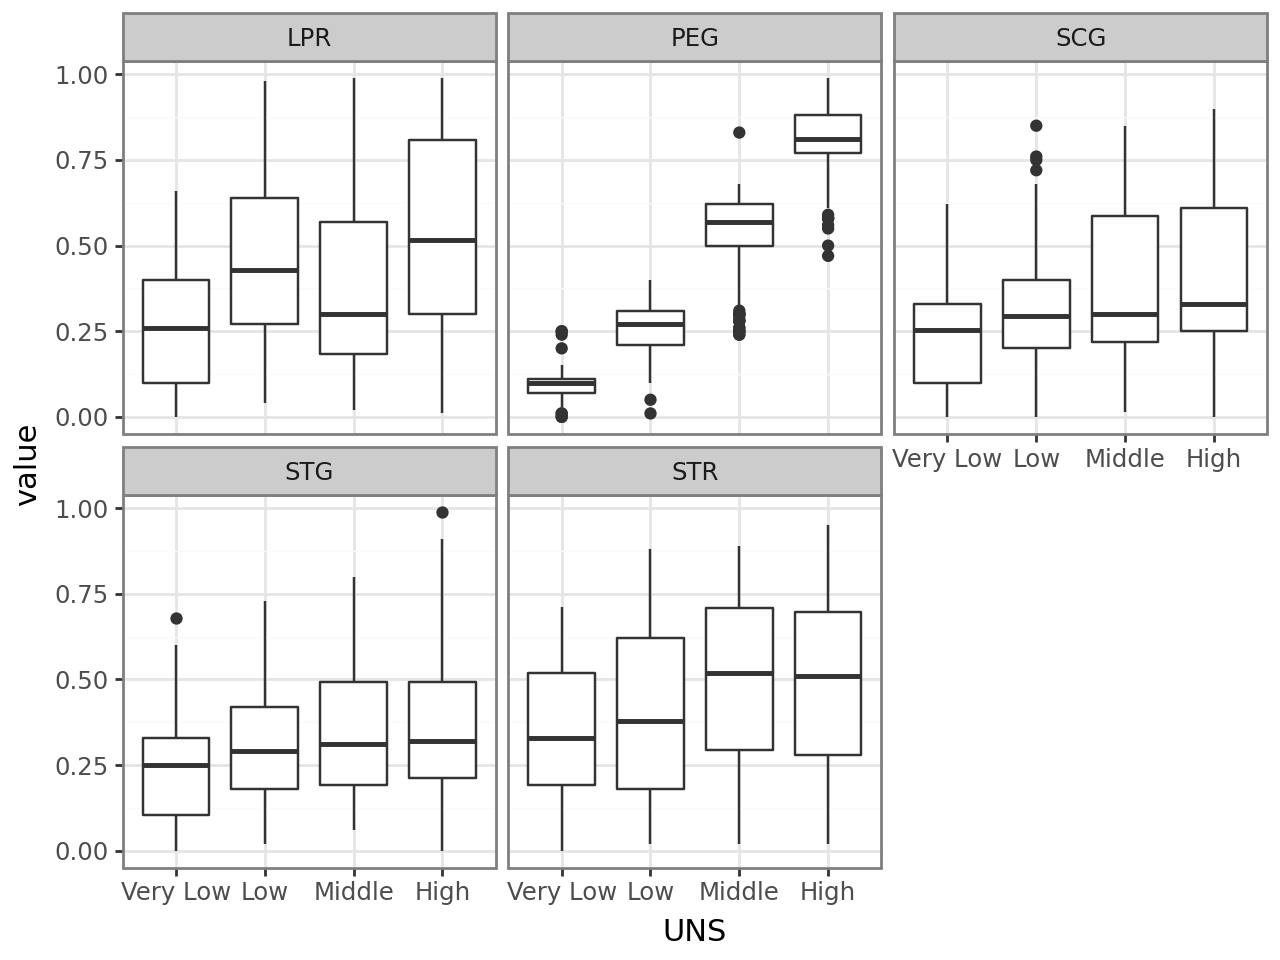

In [11]:
# melt dataframe to long format
df_long = pd.melt(
    df,
    id_vars=[c for c in df.columns if c not in ["STG", "SCG", "STR", "LPR", "PEG"]],
    value_vars=["STG", "SCG", "STR", "LPR", "PEG"],
    var_name="knowledge",
    value_name="value"
)

# ggplot boxplots of value by UNS, faceted by knowledge
p = (
    ggplot(df_long)
    + geom_boxplot(aes(x="UNS", y="value"))
    + facet_wrap("~knowledge")
    + theme_bw()
)
p

### Questions

+ Do the box plots tell us anything about the relevance of the study effort
  variables?
+ Are there immediate takeaways for our efforts to increase skills (UNS)?

## Correlation between study effort variables

In [12]:
df.drop(columns=["UNS"]).corr(method="pearson", numeric_only=True)

,STG,SCG,STR,LPR,PEG
STG,1.000000,0.049023,-0.051889,0.113957,0.198629
SCG,0.049023,1.000000,0.121235,0.119716,0.193566
STR,-0.051889,0.121235,1.000000,0.083423,0.148338
LPR,0.113957,0.119716,0.083423,1.000000,-0.039283
PEG,0.198629,0.193566,0.148338,-0.039283,1.000000


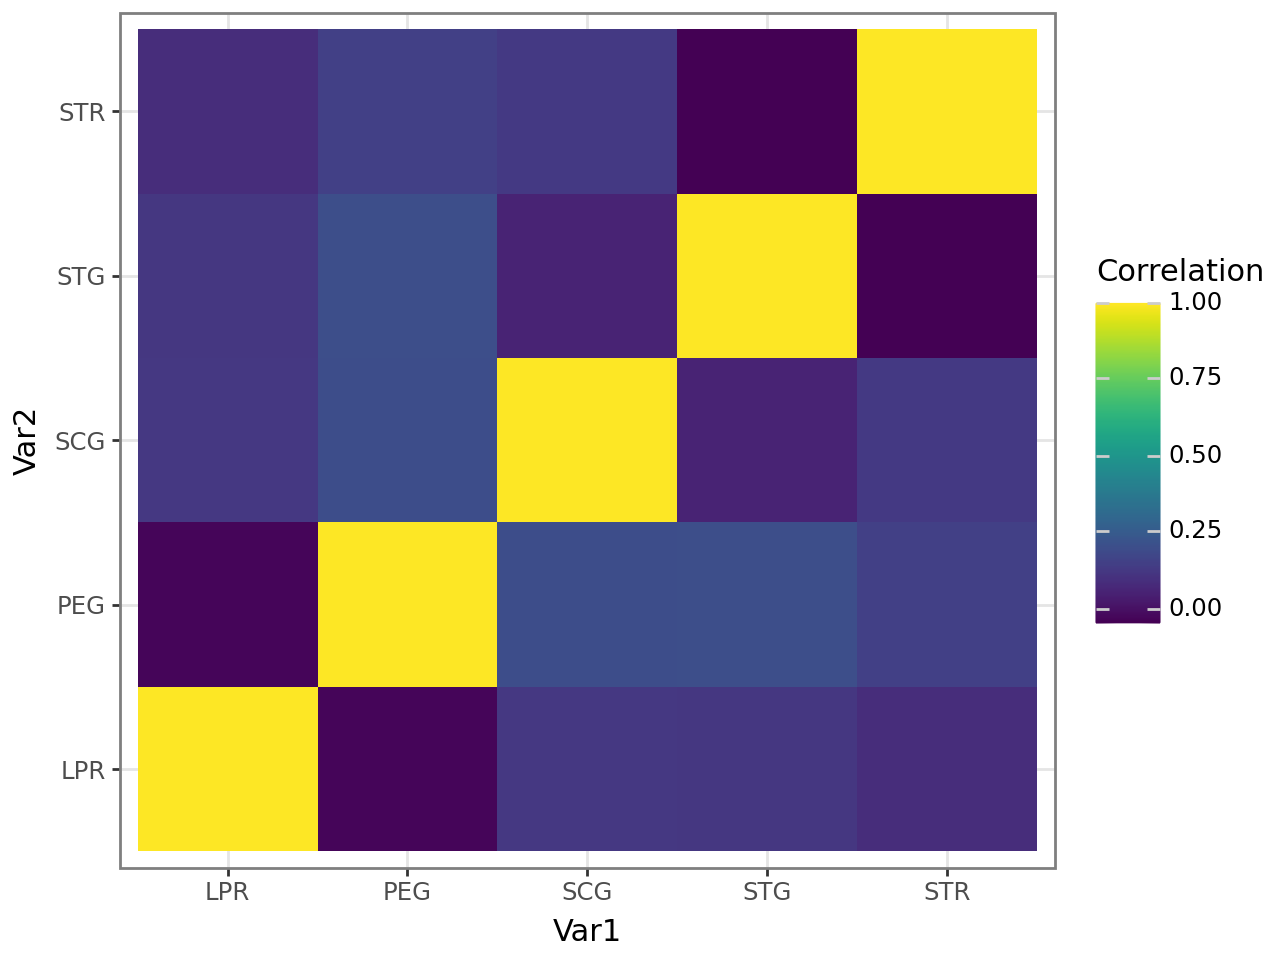

In [15]:
# Correlation of numeric predictors (drop the categorical UNS)
corr = df.drop(columns=["UNS"]).corr(method="pearson", numeric_only=True)

# Convert to long format
corr_long = (
    corr.reset_index()
        .rename(columns={"index": "Var1"})
        .melt(id_vars="Var1", var_name="Var2", value_name="Correlation")
)

# Heatmap
p = (
    ggplot(corr_long)
    + geom_tile(aes(x="Var1", y="Var2", fill="Correlation"))
    + labs(x=None, y=None)
    + theme_bw()
)
p

### Questions

+ Are there any interesting correlations between study effort variables?
+ Are there immediate takeaways for our efforts to increase skills (UNS)?

## Test the statistical signficance of differences between skill levels

In [16]:
df = df.assign(
    upper_half=df["UNS"].isin(["High", "Middle"]),
    top=df["UNS"].eq("High")
)

In [20]:
# samples
x = df.loc[df["upper_half"], "STG"].astype(float)
y = df.loc[~df["upper_half"], "STG"].astype(float)

# Welch t-test (matches R's t.test default)
t_stat, p_value = ttest_ind(x, y, equal_var=False, nan_policy="omit")
print({"t_stat": t_stat, "p_value_two_sided": p_value})

# (Optional) Add Welch-Satterthwaite dof and a 95% CI for the mean difference
n1, n2 = x.count(), y.count()
s1, s2 = x.var(ddof=1), y.var(ddof=1)
mean_diff = x.mean() - y.mean()
se2 = s1/n1 + s2/n2
se = np.sqrt(se2)
df_welch = se2**2 / ((s1**2)/((n1**2)*(n1-1)) + (s2**2)/((n2**2)*(n2-1)))

alpha = 0.05
crit = t.ppf(1 - alpha/2, df_welch)
ci_low, ci_high = mean_diff - crit*se, mean_diff + crit*se

print({
    "mean_x": x.mean(),
    "mean_y": y.mean(),
    "mean_diff": mean_diff,
    "ci_95": (ci_low, ci_high)
})

{'t_stat': np.float64(3.993597568595727), 'p_value_two_sided': np.float64(7.741492209513827e-05)}
{'mean_x': np.float64(0.3892946428571428), 'mean_y': np.float64(0.3078994413407821), 'mean_diff': np.float64(0.0813952015163607), 'ci_95': (np.float64(0.0413274135246272), np.float64(0.1214629895080942))}


In [19]:
# samples
x = df.loc[df["top"], "STG"].astype(float)
y = df.loc[~df["top"], "STG"].astype(float)

# Welch t-test (matches R's t.test default)
t_stat, p_value = ttest_ind(x, y, equal_var=False, nan_policy="omit")
print({"t_stat": t_stat, "p_value_two_sided": p_value})

# (Optional) Add Welch-Satterthwaite dof and a 95% CI for the mean difference
n1, n2 = x.count(), y.count()
s1, s2 = x.var(ddof=1), y.var(ddof=1)
mean_diff = x.mean() - y.mean()
se2 = s1/n1 + s2/n2
se = np.sqrt(se2)
df_welch = se2**2 / ((s1**2)/((n1**2)*(n1-1)) + (s2**2)/((n2**2)*(n2-1)))

alpha = 0.05
crit = t.ppf(1 - alpha/2, df_welch)
ci_low, ci_high = mean_diff - crit*se, mean_diff + crit*se

print({
    "mean_x": x.mean(),
    "mean_y": y.mean(),
    "mean_diff": mean_diff,
    "ci_95": (ci_low, ci_high)
})

{'t_stat': np.float64(2.6761209678054074), 'p_value_two_sided': np.float64(0.008295120625952283)}
{'mean_x': np.float64(0.4069019607843138), 'mean_y': np.float64(0.33492358803986716), 'mean_diff': np.float64(0.07197837274444663), 'ci_95': (np.float64(0.018823691487577204), np.float64(0.12513305400131605))}


In [24]:
# One-way ANOVA: STG ~ UNS
# SciPy quick result (F and p-value)
groups = [g["STG"].dropna().to_numpy()
          for _, g in df.groupby("UNS", observed=False)]
F_scipy, p_scipy = stats.f_oneway(*groups)

print({"scipy_f_oneway": {"F": F_scipy, "p_value": p_scipy}})

{'scipy_f_oneway': {'F': np.float64(6.823890440570518), 'p_value': np.float64(0.00017066155796904283)}}


### Questions

+ How are these results different from the previous ones?
+ What do you think about the results of the t-test and ANOVA?
+ Are there immediate takeaways for our efforts to increase skills (UNS)?
+ What analyses should we do next?
